### 8. Pytorch paper replicating

In this project, we're going to be replicating a machine learning research paper and creating a Vision Transformer (ViT) from scratch using PyTorch.

We'll then see how ViT, a state-of-the-art computer vision architecture, performs on our FoodVision Mini problem.



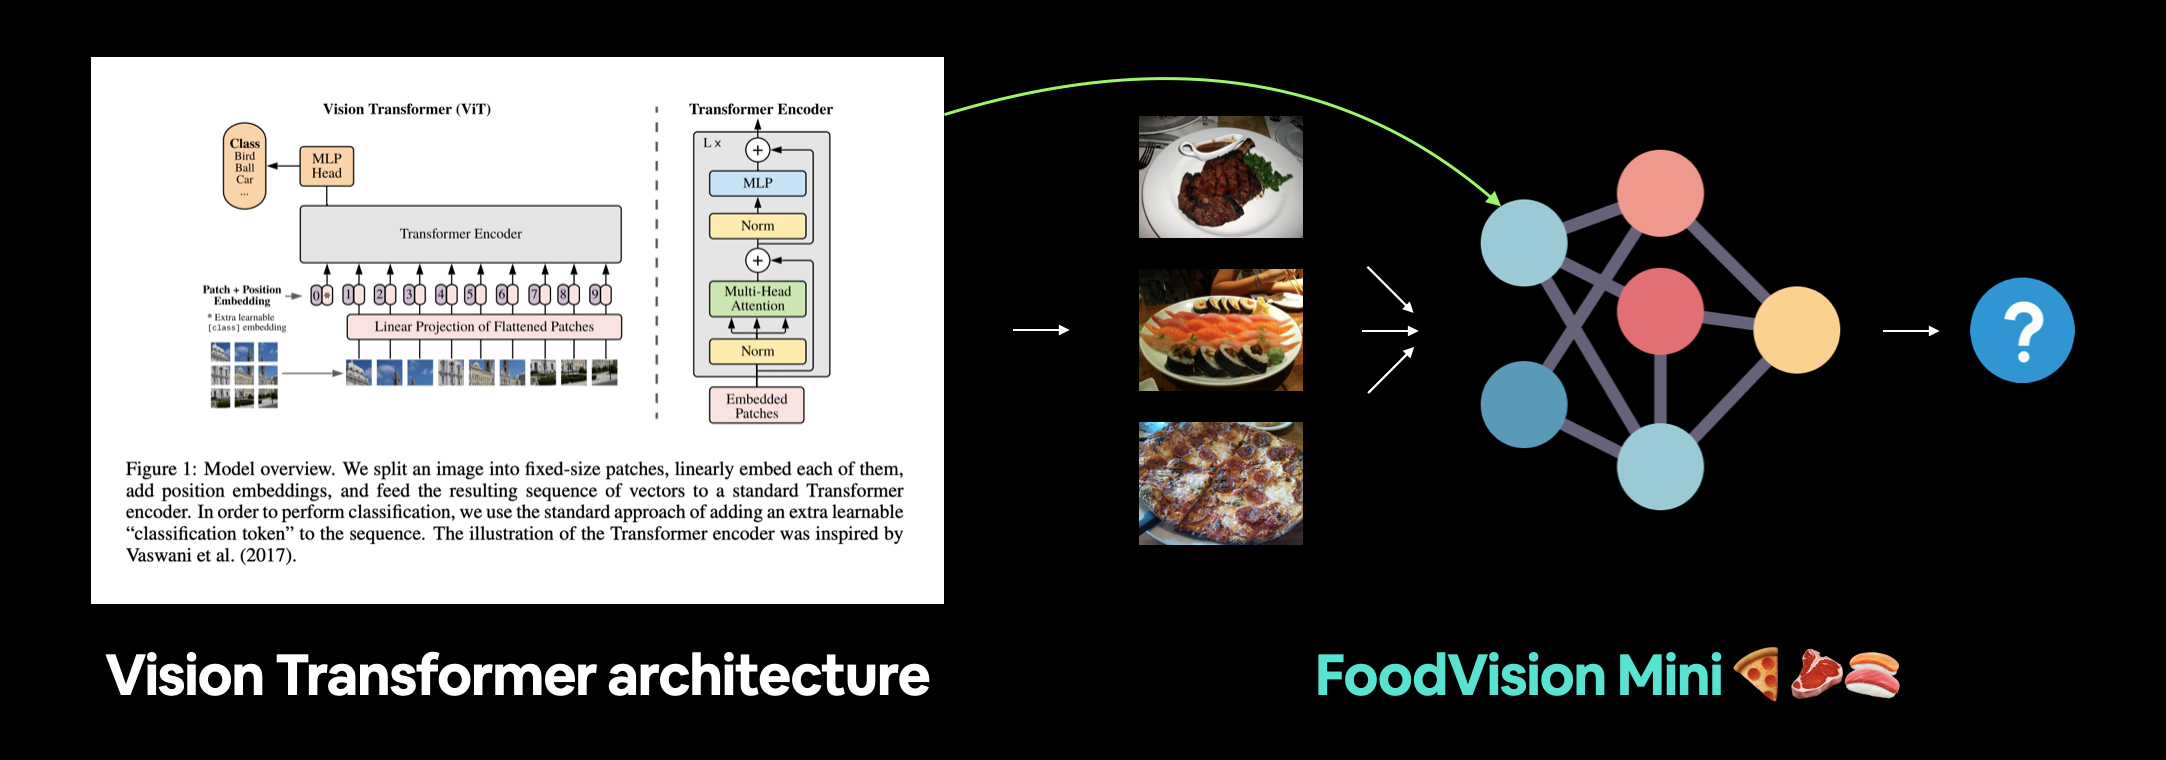

### What is paper replicating?

Many of these advances get published in machine learning research papers.

And the goal of paper replicating is to replicate these advances with code so you can use the techniques for your own problem.

For example, let's say a new model architecture gets released that performs better than any other architecture before on various benchmarks, wouldn't it be nice to try that architecture on your own problems?

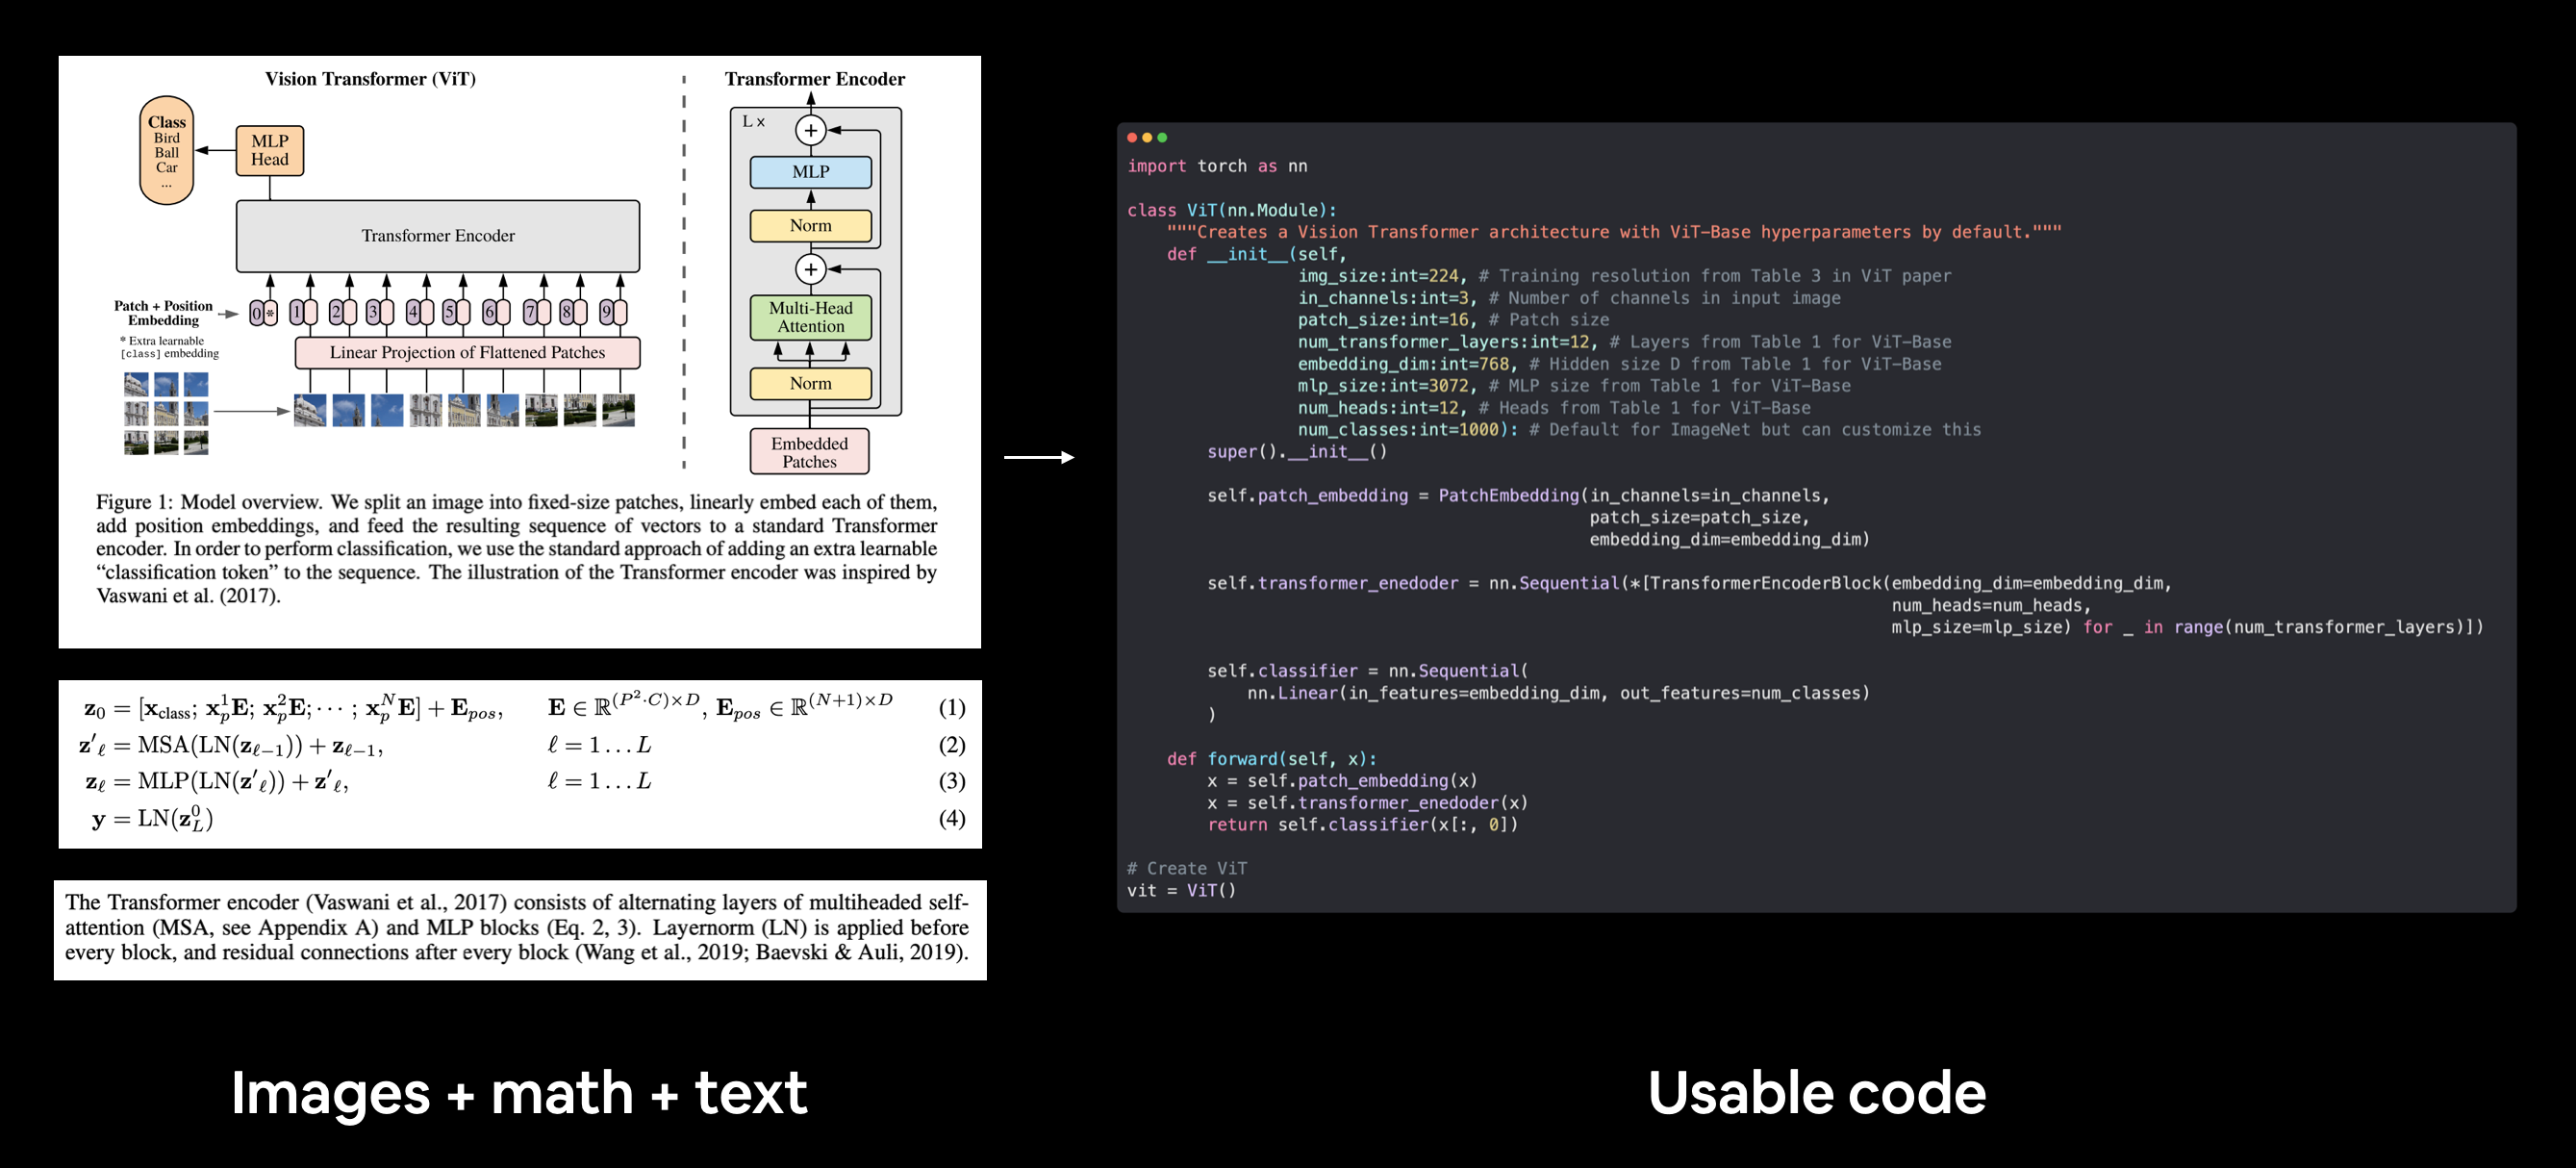

#### What is a machine learning research paper?

A machine learning research paper is a scientific paper that details findings of a research group on a specific area.

| Section | Contents |
| :--- | :--- |
| **Abstract** | An overview/summary of the paper's main findings/contributions. |
| **Introduction** | What's the paper's main problem and details of previous methods used to try and solve it. |
| **Method** | How did the researchers go about conducting their research? For example, what model(s), data sources, training setups were used? |
| **Results** | What are the outcomes of the paper? If a new type of model or training setup was used, how did the results of findings compare to previous works? (this is where **experiment tracking** comes in handy) |
| **Conclusion** | What are the limitations of the suggested methods? What are some next steps for the research community? |
| **References** | What resources/other papers did the researchers look at to build their own body of work? |
| **Appendix** | Are there any extra resources/findings to look at that weren't included in any of the above sections? |

## 0.Getting setup

In [3]:
import torch 
from torchinfo import summary
import matplotlib.pyplot as plt 
import torchvision
from torchvision import transforms
from torch import nn
import requests
from helper_function import download_data

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. Get Data

In [6]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] Did not find data\pizza_steak_sushi directory, creating one...
[INFO] Downloading pizza_steak_sushi.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip...
[INFO] Unzipping pizza_steak_sushi.zip data...


WindowsPath('data/pizza_steak_sushi')

In [7]:
train_dir = image_path / "train"
test_dir = image_path / "test"

## 2. Creating Datasets and Dataloaders

First, we'll create a transform to prepare our images.

This where one of the first references to the ViT paper will come in.

In Table 3, the training resolution is mentioned as being 224 (height=224, width=224).

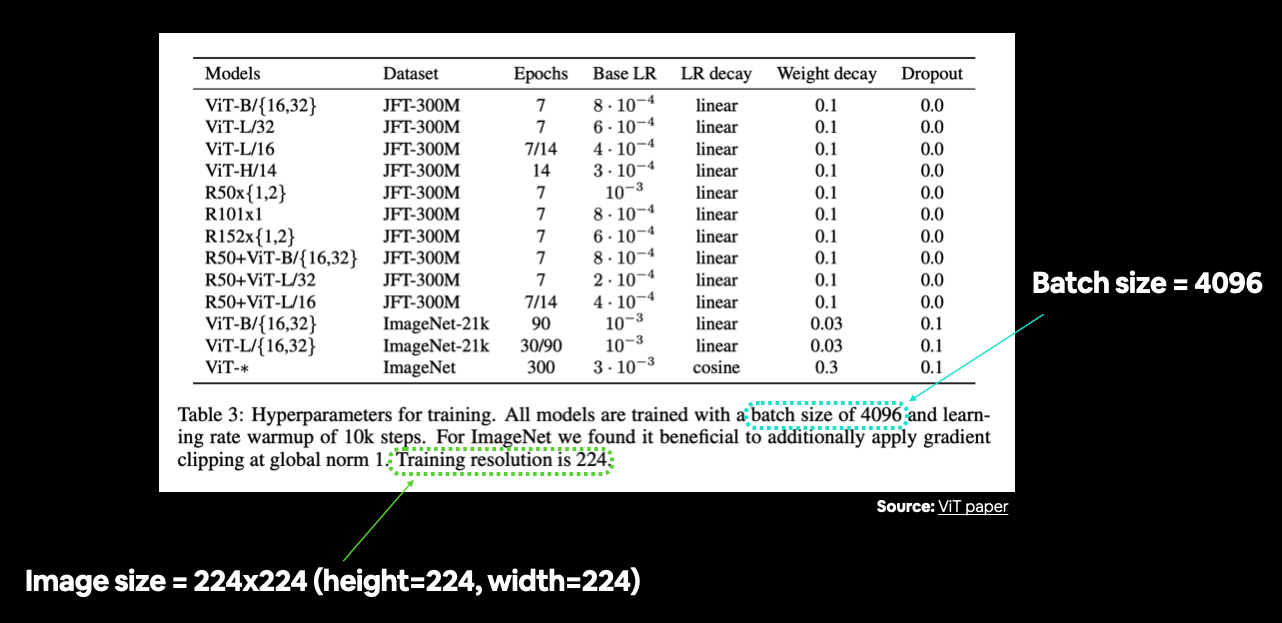

You can often find various hyperparameter settings listed in a table. In this case we're still preparing our data, so we're mainly concerned with things like image size and batch size. Source: Table 3 in ViT paper.

So we'll make sure our transform resizes our images appropriately.

And since we'll be training our model from scratch (no transfer learning to begin with), we won't provide a normalize transform like we did in 06. PyTorch Transfer Learning section 2.1.

### 2.1 Prepare transforms for images

In [10]:
IMG_SIZE = 224
manual_transform = transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                    transforms.ToTensor()
])

print(f"Manually created transform : {manual_transform}")


Manually created transform : Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


### 2.2 Turn images into `Dataloader`'s

Transforms created!

Let's now create our DataLoader's.

The ViT paper states the use of a batch size of 4096 which is 128x the size of the batch size we've been using (32).

However, we're going to stick with a batch size of 32.


In [21]:
import data_setup

BATCH_SIZE = 32
train_dataloader , test_dataloader ,class_names , class_dict = data_setup.create_dataloaders(train_dir = train_dir,test_dir = test_dir,
train_transform =manual_transform,test_transform = manual_transform, batch_size = BATCH_SIZE)

train_dataloader,test_dataloader,class_names,class_dict

(<torch.utils.data.dataloader.DataLoader at 0x188b5223670>,
 ['pizza', 'steak', 'sushi'],
 {'pizza': 0, 'steak': 1, 'sushi': 2})